In [1]:
import torch
import re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib inline

In [2]:
TOKEN_SPLITTER_REGEXP = r'([,.:;?_!"()\']|--|\s)'
PUNCTUATIONS_REGEXP = r'\s+([,.!?"()\'])'
TOK_UNKNOWN = '|<unk>|'
TOK_EOT = '|<endoftext>|'

In [3]:
class SimpleTokenizer:

    def __init__(self, vocab: list[str]):
        vocab.extend([TOK_UNKNOWN, TOK_EOT])
        self.int_to_token = {i: token for i, token in enumerate(vocab)}
        self.token_to_int = {t: i for i, t in enumerate(vocab)}

    # text to list of integer encoding
    def encode(self, text: str) -> list[int]:
        # preprocessing
        tokens = re.split(TOKEN_SPLITTER_REGEXP, text)
        preprocessed = []

        for token in tokens:
            stripped_token = token.strip()
            if stripped_token:
                preprocessed.append(stripped_token)

        encodings = []

        for token in preprocessed:
            encoding = self.token_to_int.get(token)
            if encoding is not None:
                encodings.append(encoding)
            else:
                print(encoding)
                print(self.token_to_int.get(token))
                encodings.append(self.token_to_int.get(TOK_UNKNOWN))

        return encodings

    # integer encodings to text
    def decode(self, encodings: list[int]) -> str:
        text = ' '.join([self.int_to_token[enc] for enc in encodings])
        # Replace spaces before the specified punctuations
        text = re.sub(PUNCTUATIONS_REGEXP, r'\1', text)
        return text


In [4]:
def build_vocabulary(raw_text: str) -> list[str]:
    all_tokens = re.split(TOKEN_SPLITTER_REGEXP, raw_text)
    preprocessed = [token.strip() for token in all_tokens if token.strip()]
    return sorted(list(set(preprocessed)))

In [5]:
def plot_vectors(vectors, words, title="No title"):
    xs = vectors[:, 0]
    ys = vectors[:, 1]
    zs = vectors[:, 2]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

    for (x, y, z, word, color) in zip(xs, ys, zs, words, colors):
        ax.quiver(0, 0, 0, 
                  x.item(), y.item(), z.item(), color=color, arrow_length_ratio=0.1, linewidth=1)
        ax.text(x.item(), y.item(), z.item(), word, fontsize=10, color=color)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    plt.title(title)

### Implement attention mechanism without trainable weights

In [6]:
input_text = "Every journey begins with a single step."

vocab = build_vocabulary(input_text)

context_len = 4

simple_tokenizer = SimpleTokenizer(vocab)

In [7]:
encodings = simple_tokenizer.encode(input_text)
print("Input: ", input_text)
print("Encodings: ", encodings)

Input:  Every journey begins with a single step.
Encodings:  [1, 4, 3, 7, 2, 5, 6, 0]


In [8]:
torch.manual_seed(0)

In [9]:
# use 3 dimensional vectors for embeddings
embedding_dim = 3
word_embeddings = torch.nn.Embedding(len(vocab), embedding_dim)
positional_embedding = torch.nn.Embedding(context_len, embedding_dim)

In [10]:
word_embeddings.weight, positional_embedding.weight

(Parameter containing:
 tensor([[-1.1258, -1.1524, -0.2506],
         [-0.4339,  0.8487,  0.6920],
         [-0.3160, -2.1152,  0.3223],
         [-1.2633,  0.3500,  0.3081],
         [ 0.1198,  1.2377, -0.1435],
         [-0.1116, -0.6136,  0.0316],
         [-0.4927,  0.2484,  0.4397],
         [ 0.1124, -0.8411, -2.3160],
         [-0.1023,  0.7924, -0.2897],
         [ 0.0525,  0.5229,  2.3022]], requires_grad=True),
 Parameter containing:
 tensor([[-0.7079, -0.1064, -1.2427],
         [-0.4762, -0.6859, -1.5051],
         [ 0.2550,  1.8042, -0.4502],
         [-0.4830,  0.6577,  0.9387]], requires_grad=True))

In [11]:
# processing a single context out of the batch
print(encodings[0:context_len])
words = [simple_tokenizer.decode([e]) for e in encodings[0:context_len]]
print(words)
word_emb = word_embeddings(torch.tensor(encodings[0:context_len]))
pos_emb = positional_embedding(torch.arange(0, context_len))
word_emb, pos_emb

[1, 4, 3, 7]
['Every', 'journey', 'begins', 'with']


(tensor([[-0.4339,  0.8487,  0.6920],
         [ 0.1198,  1.2377, -0.1435],
         [-1.2633,  0.3500,  0.3081],
         [ 0.1124, -0.8411, -2.3160]], grad_fn=<EmbeddingBackward0>),
 tensor([[-0.7079, -0.1064, -1.2427],
         [-0.4762, -0.6859, -1.5051],
         [ 0.2550,  1.8042, -0.4502],
         [-0.4830,  0.6577,  0.9387]], grad_fn=<EmbeddingBackward0>))

In [12]:
input_embeddigs = word_emb + pos_emb
print(input_embeddigs)

tensor([[-1.1418,  0.7423, -0.5507],
        [-0.3564,  0.5517, -1.6486],
        [-1.0084,  2.1542, -0.1421],
        [-0.3706, -0.1834, -1.3774]], grad_fn=<AddBackward0>)


In [14]:
attention_score = input_embeddigs @ input_embeddigs.T
print(attention_score)

tensor([[2.1579, 1.7244, 2.8286, 1.0456],
        [1.7244, 3.1494, 1.7822, 2.3017],
        [2.8286, 1.7822, 5.6777, 0.1745],
        [1.0456, 2.3017, 0.1745, 2.0682]], grad_fn=<MmBackward0>)


In [15]:
attention_weights = torch.softmax(attention_score, dim=-1)
attention_weights

tensor([[0.2543, 0.1648, 0.4973, 0.0836],
        [0.1250, 0.5198, 0.1325, 0.2227],
        [0.0535, 0.0188, 0.9240, 0.0038],
        [0.1297, 0.4554, 0.0543, 0.3606]], grad_fn=<SoftmaxBackward0>)

In [16]:
context_embedding = attention_weights @ input_embeddigs
print(context_embedding)

tensor([[-0.8815,  1.3356, -0.5976],
        [-0.5441,  0.6241, -1.2514],
        [-1.0008,  2.0398, -0.1969],
        [-0.4988,  0.3984, -1.3267]], grad_fn=<MmBackward0>)


In [17]:
xs = context_embedding[:, 0]
ys = context_embedding[:, 1]
zs = context_embedding[:, 2]
xs

tensor([-0.8815, -0.5441, -1.0008, -0.4988], grad_fn=<SelectBackward0>)

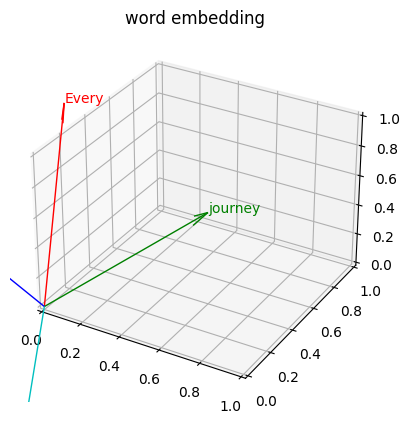

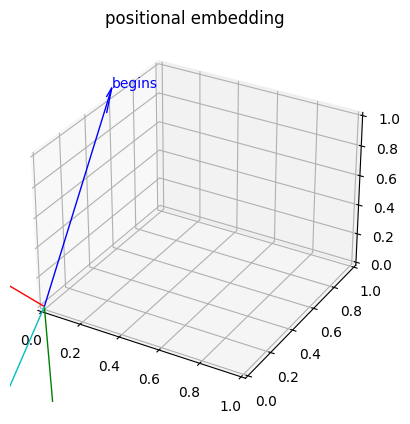

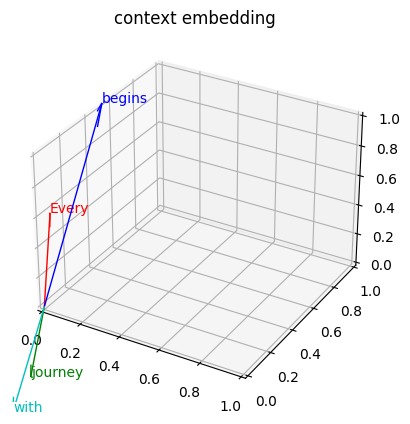

In [18]:
plot_vectors(word_emb, words, "word embedding")
plot_vectors(input_embeddigs, words, "positional embedding")
plot_vectors(context_embedding, words, "context embedding")

### Attention with trainable weights

In [19]:
# for each input encoding we create trainable query, key and value of lower dimension

In [20]:
words
encodings[0:context_len]

[1, 4, 3, 7]

In [25]:
input_embeddigs, input_embeddigs.shape

(tensor([[-1.1418,  0.7423, -0.5507],
         [-0.3564,  0.5517, -1.6486],
         [-1.0084,  2.1542, -0.1421],
         [-0.3706, -0.1834, -1.3774]], grad_fn=<AddBackward0>),
 torch.Size([4, 3]))

In [26]:
W_key = torch.nn.Linear(3, 2, bias=False)
W_key.weight

Parameter containing:
tensor([[ 0.2220, -0.3420,  0.2117],
        [ 0.2920,  0.4133,  0.2159]], requires_grad=True)

In [27]:
input_embeddigs @ W_key.weight.T # same as the line below

tensor([[-0.6239, -0.1455],
        [-0.6167, -0.2319],
        [-0.9906,  0.5653],
        [-0.3111, -0.4813]], grad_fn=<MmBackward0>)

In [28]:
W_key(input_embeddigs) # also known as keys 

tensor([[-0.6239, -0.1455],
        [-0.6167, -0.2319],
        [-0.9906,  0.5653],
        [-0.3111, -0.4813]], grad_fn=<MmBackward0>)

In [33]:
class SelfAttentionWithTrainableWeightsV1(torch.nn.Module):
    def __init__(self, dim_in, dim_out, qkv_bias=False):
        super().__init__()
        # self.query = torch.nn.Parameter(dim_in, dim_out)
        self.W_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attention_score = queries @ keys.T
        print("Attention score", attention_score, attention_score.shape)
        attention_weights = torch.softmax(attention_score/keys.shape[-1]**0.5, dim=-1)

        context_vec = attention_weights @ values
        return context_vec



In [34]:
input_embeddigs.shape

torch.Size([4, 3])

In [35]:
self_attention = SelfAttentionWithTrainableWeightsV1(embedding_dim, 2)

In [36]:
context_vector = self_attention.forward(input_embeddigs)
context_vector

Attention score tensor([[-0.2418, -0.4565, -0.1942, -0.3575],
        [ 0.0079,  0.0464, -0.0772,  0.0704],
        [-0.2411, -0.5777,  0.1328, -0.5855],
        [-0.0073,  0.0619, -0.2072,  0.1305]], grad_fn=<MmBackward0>) torch.Size([4, 4])


tensor([[0.2456, 0.4551],
        [0.2618, 0.4911],
        [0.2097, 0.4000],
        [0.2723, 0.5075]], grad_fn=<MmBackward0>)

In [37]:
context_vector.shape

torch.Size([4, 2])

Why do we need to scale with square root of dimension ?

Scaling like this will enable us to keep the variance of the series to 1

In [38]:
dot_products = []
scaled_dot_products = []

for _ in range(100):
    dim = 3
    k = np.random.randn(dim)
    v = np.random.randn(dim)
    
    dot_product = np.dot(k,v)
    scaled_dot_product = np.dot(k,v) / dim**0.5
    
    dot_products.append(dot_product)
    scaled_dot_products.append(scaled_dot_product)

np.var(dot_products), np.var(scaled_dot_products)

(1.7413784923463087, 0.5804594974487698)

### Causal attention 

In [135]:
class CausualAttention(torch.nn.Module):
    def __init__(self, dim_in, dim_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
        self.dropout = torch.nn.Dropout(dropout)
        # these are not part of model parameters and are not part of traininig
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, batch):
        batch_size, num_tokens, d_in = batch.shape
        queries = self.W_query(batch)
        keys = self.W_key(batch)
        values = self.W_value(batch)

        attention_score = queries @ keys.transpose(1, 2)
        #print("Attention score", attention_score, attention_score.shape)
        attention_score = attention_score.masked_fill(self.mask.bool(), -torch.inf)
        attention_weights = torch.softmax(attention_score/keys.shape[-1]**0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)

        context_vec = attention_weights @ values
        return context_vec


In [42]:
# creating a batch of multiple inputs
batch = torch.stack((input_embeddigs, input_embeddigs), dim=0)

In [44]:
batch, batch.shape

(tensor([[[-1.1418,  0.7423, -0.5507],
          [-0.3564,  0.5517, -1.6486],
          [-1.0084,  2.1542, -0.1421],
          [-0.3706, -0.1834, -1.3774]],
 
         [[-1.1418,  0.7423, -0.5507],
          [-0.3564,  0.5517, -1.6486],
          [-1.0084,  2.1542, -0.1421],
          [-0.3706, -0.1834, -1.3774]]], grad_fn=<StackBackward0>),
 torch.Size([2, 4, 3]))

In [67]:
test_batch = torch.stack((torch.randn(1,3), torch.randn(1,3)), dim=0)

In [69]:
test_batch, test_batch.transpose(1,2)

(tensor([[[-0.3552, -0.7219, -0.3061]],
 
         [[ 1.3768,  1.0055, -0.2455]]]),
 tensor([[[-0.3552],
          [-0.7219],
          [-0.3061]],
 
         [[ 1.3768],
          [ 1.0055],
          [-0.2455]]]))

In [78]:
dropout = torch.nn.Dropout(0.5) # 50%

In [76]:
dropout(test_batch) # randomly switch off the values in a tensor

tensor([[[-0.0000, -1.4438, -0.0000]],

        [[ 0.0000,  2.0109, -0.4911]]])

In [99]:
mask = torch.triu(torch.ones(5,5), diagonal=1)
mask

tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]])

In [111]:
test_attention_score = torch.randn(5,5)
test_attention_score

tensor([[ 0.2329,  0.0364,  0.4070,  1.2516, -1.1991],
        [-0.0257,  1.8024, -1.0597, -0.0044, -0.0965],
        [ 0.3303, -0.1875,  1.0609, -0.0160,  1.2757],
        [ 0.0095, -0.3694, -0.9161,  1.5599, -3.1537],
        [ 1.4044,  1.0829,  0.7890, -0.1376,  0.1225]])

In [112]:
# masking
mask.bool()
masked_score = test_attention_score.masked_fill(mask.bool(), -torch.inf)
masked_score

tensor([[ 0.2329,    -inf,    -inf,    -inf,    -inf],
        [-0.0257,  1.8024,    -inf,    -inf,    -inf],
        [ 0.3303, -0.1875,  1.0609,    -inf,    -inf],
        [ 0.0095, -0.3694, -0.9161,  1.5599,    -inf],
        [ 1.4044,  1.0829,  0.7890, -0.1376,  0.1225]])

In [113]:
torch.softmax(masked_score, dim=1) 

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1385, 0.8615, 0.0000, 0.0000, 0.0000],
        [0.2723, 0.1623, 0.5654, 0.0000, 0.0000],
        [0.1472, 0.1008, 0.0583, 0.6937, 0.0000],
        [0.3627, 0.2630, 0.1960, 0.0776, 0.1007]])

In [137]:
ca = CausualAttention(3, 2, batch.shape[1], 0.5)

In [138]:
ca(batch) # new context vector after causal attention mechanism

tensor([[[ 0.0000,  0.0000],
         [-1.6948, -0.7910],
         [-0.9999, -0.4981],
         [-0.3632, -0.0390]],

        [[ 0.0000,  0.0000],
         [ 0.0000,  0.0000],
         [-1.2601, -0.0159],
         [-0.5458,  0.3512]]], grad_fn=<UnsafeViewBackward0>)